In [11]:
import pandas as pd
import numpy as np

# Input file
input_path = r"D:\bitirme\merged_synergy_named.csv"

df = pd.read_csv(input_path)

# Keep only rows with Bliss available
df_bliss = df[df["bliss"].notna()].copy()

# Make drug pairs order-independent
df_bliss["drugA_id"] = df_bliss[["drug1_id", "drug2_id"]].min(axis=1)
df_bliss["drugB_id"] = df_bliss[["drug1_id", "drug2_id"]].max(axis=1)

df_bliss["drugA_name"] = np.where(
    df_bliss["drug1_id"] <= df_bliss["drug2_id"],
    df_bliss["drug1_name"],
    df_bliss["drug2_name"]
)

df_bliss["drugB_name"] = np.where(
    df_bliss["drug1_id"] <= df_bliss["drug2_id"],
    df_bliss["drug2_name"],
    df_bliss["drug1_name"]
)

print(df_bliss.shape)
df_bliss.head()

(66300, 12)


,drug1_id,drug2_id,drug1_name,drug2_name,cell_line,bliss,gamma,source,drugA_id,drugB_id,drugA_name,drugB_name
0,DRMCATBEKSVAPL-UHFFFAOYSA-N,LXZZYRPGZAFOLE-UHFFFAOYSA-L,Oxaliplatin,Cisplatin,PL4,3.008337,NaN,GDSC,DRMCATBEKSVAPL-UHFFFAOYSA-N,LXZZYRPGZAFOLE-UHFFFAOYSA-L,Oxaliplatin,Cisplatin
1,LXZZYRPGZAFOLE-UHFFFAOYSA-L,UWKQSNNFCGGAFS-UHFFFAOYSA-N,Cisplatin,Irinotecan,PL4,-1.685581,NaN,GDSC,LXZZYRPGZAFOLE-UHFFFAOYSA-L,UWKQSNNFCGGAFS-UHFFFAOYSA-N,Cisplatin,Irinotecan
2,LXZZYRPGZAFOLE-UHFFFAOYSA-L,ZBNZXTGUTAYRHI-UHFFFAOYSA-N,Cisplatin,Dasatinib,PL4,-0.036956,NaN,GDSC,LXZZYRPGZAFOLE-UHFFFAOYSA-L,ZBNZXTGUTAYRHI-UHFFFAOYSA-N,Cisplatin,Dasatinib
3,LXZZYRPGZAFOLE-UHFFFAOYSA-L,PKCDDUHJAFVJJB-UHFFFAOYSA-N,Cisplatin,Linsitinib,PL4,-1.114912,NaN,GDSC,LXZZYRPGZAFOLE-UHFFFAOYSA-L,PKCDDUHJAFVJJB-UHFFFAOYSA-N,Cisplatin,Linsitinib
4,LXZZYRPGZAFOLE-UHFFFAOYSA-L,ULDXWLCXEDXJGE-UHFFFAOYSA-N,Cisplatin,MK-2206,PL4,0.606587,NaN,GDSC,LXZZYRPGZAFOLE-UHFFFAOYSA-L,ULDXWLCXEDXJGE-UHFFFAOYSA-N,Cisplatin,MK-2206


In [12]:
triplet_stats = (
    df_bliss
    .groupby(["drugA_id", "drugB_id", "drugA_name", "drugB_name", "cell_line"], as_index=False)
    .agg(
        replicate_count=("bliss", "size"),
        bliss_mean=("bliss", "mean"),
        bliss_variance=("bliss", lambda x: np.var(x, ddof=1) if len(x) > 1 else 0.0),
        bliss_std=("bliss", lambda x: np.std(x, ddof=1) if len(x) > 1 else 0.0),
        bliss_min=("bliss", "min"),
        bliss_max=("bliss", "max"),
    )
)

print(triplet_stats.shape)
triplet_stats.head()

(9397, 11)


,drugA_id,drugB_id,drugA_name,drugB_name,cell_line,replicate_count,bliss_mean,bliss_variance,bliss_std,bliss_min,bliss_max
0,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AHJRHEGDXFFMBM-UHFFFAOYSA-N,Erlotinib,Palbociclib,AsPC-1,4,0.754391,0.999393,0.999696,-0.157673,1.875962
1,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AHJRHEGDXFFMBM-UHFFFAOYSA-N,Erlotinib,Palbociclib,BxPC-3,6,-0.108611,0.847739,0.920727,-1.224653,0.937918
2,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AHJRHEGDXFFMBM-UHFFFAOYSA-N,Erlotinib,Palbociclib,CAPAN-1,4,-0.096525,1.609169,1.268530,-1.992016,0.660782
3,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AHJRHEGDXFFMBM-UHFFFAOYSA-N,Erlotinib,Palbociclib,CAPAN-2,4,-0.899915,1.721776,1.312165,-2.291631,0.430358
4,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AHJRHEGDXFFMBM-UHFFFAOYSA-N,Erlotinib,Palbociclib,CFPAC-1,4,-0.906232,0.473787,0.688322,-1.596031,0.021761


In [13]:
Q1 = triplet_stats["bliss_mean"].quantile(0.25)
Q2 = triplet_stats["bliss_mean"].quantile(0.50)
Q3 = triplet_stats["bliss_mean"].quantile(0.75)

print("Q1:", Q1)
print("Median:", Q2)
print("Q3:", Q3)

Q1: -0.8386991786153846
Median: -0.02995642750000002
Q3: 0.844086120625


In [14]:
def quartile_class(x, q1, q3):
    if x < q1:
        return "synergistically_negative"
    elif x > q3:
        return "synergistically_positive"
    else:
        return "uncertain"

triplet_stats["synergy_class_q"] = triplet_stats["bliss_mean"].apply(lambda x: quartile_class(x, Q1, Q3))

# Optional binary encoding for only confident triplets
# negative = 0, positive = 1, uncertain = NaN
triplet_stats["synergy_binary_q"] = np.where(
    triplet_stats["bliss_mean"] < Q1, 0,
    np.where(triplet_stats["bliss_mean"] > Q3, 1, np.nan)
)

triplet_stats["is_uncertain"] = triplet_stats["synergy_class_q"] == "uncertain"

triplet_stats["synergy_class_q"].value_counts(dropna=False)

synergy_class_q
uncertain                   4699
synergistically_negative    2349
synergistically_positive    2349
Name: count, dtype: int64

In [15]:
var_q1 = triplet_stats["bliss_variance"].quantile(0.25)
var_q3 = triplet_stats["bliss_variance"].quantile(0.75)
var_iqr = var_q3 - var_q1

variance_threshold_iqr = var_q3 + 1.5 * var_iqr

triplet_stats["high_variance_iqr"] = triplet_stats["bliss_variance"] > variance_threshold_iqr

print("Variance Q1:", var_q1)
print("Variance Q3:", var_q3)
print("Variance threshold (IQR rule):", variance_threshold_iqr)
print("High variance triplets:", triplet_stats["high_variance_iqr"].sum())

Variance Q1: 0.5750156203734602
Variance Q3: 2.2841347513983314
Variance threshold (IQR rule): 4.847813447935638
High variance triplets: 695


In [16]:
# 1. Full aggregated triplet file
triplet_all = triplet_stats.copy()

# 2. Remove only high-variance triplets (IQR rule)
triplet_filtered_iqr = triplet_stats[~triplet_stats["high_variance_iqr"]].copy()

# 3. Keep only confident quartile labels, but do not filter by variance
triplet_confident_only = triplet_stats[triplet_stats["synergy_class_q"] != "uncertain"].copy()

# 4. Keep confident quartile labels and remove high-variance triplets
triplet_confident_filtered_iqr = triplet_stats[
    (triplet_stats["synergy_class_q"] != "uncertain") &
    (~triplet_stats["high_variance_iqr"])
].copy()

print("All triplets:", triplet_all.shape)
print("Filtered by variance (IQR):", triplet_filtered_iqr.shape)
print("Confident only:", triplet_confident_only.shape)
print("Confident + filtered:", triplet_confident_filtered_iqr.shape)

All triplets: (9397, 15)
Filtered by variance (IQR): (8702, 15)
Confident only: (4698, 15)
Confident + filtered: (4231, 15)


In [17]:
output_dir = r"D:\bitirme"

triplet_all.to_csv(fr"{output_dir}\triplet_stats_quartiles_all.csv", index=False)
triplet_filtered_iqr.to_csv(fr"{output_dir}\triplet_stats_quartiles_filtered_iqr.csv", index=False)
triplet_confident_only.to_csv(fr"{output_dir}\triplet_stats_quartiles_confident_only.csv", index=False)
triplet_confident_filtered_iqr.to_csv(fr"{output_dir}\triplet_stats_quartiles_confident_filtered_iqr.csv", index=False)

print("Files saved.")

Files saved.


In [18]:
print("\nClass distribution:")
print(triplet_stats["synergy_class_q"].value_counts())

print("\nReplicate count distribution:")
print(triplet_stats["replicate_count"].describe())

print("\nVariance distribution:")
print(triplet_stats["bliss_variance"].describe())

print("\nTop 10 highest variance triplets:")
display(
    triplet_stats.sort_values("bliss_variance", ascending=False).head(10)
)


Class distribution:
synergy_class_q
uncertain                   4699
synergistically_negative    2349
synergistically_positive    2349
Name: count, dtype: int64

Replicate count distribution:
count    9397.000000
mean        7.055443
std         5.858703
min         2.000000
25%         4.000000
50%         4.000000
75%         8.000000
max        40.000000
Name: replicate_count, dtype: float64

Variance distribution:
count    9397.000000
mean        1.866725
std         2.380773
min         0.000008
25%         0.575016
50%         1.164658
75%         2.284135
max        69.308170
Name: bliss_variance, dtype: float64

Top 10 highest variance triplets:


,drugA_id,drugB_id,drugA_name,drugB_name,cell_line,replicate_count,bliss_mean,bliss_variance,bliss_std,bliss_min,bliss_max,synergy_class_q,synergy_binary_q,is_uncertain,high_variance_iqr
496,AAKJLRGGTJKAMG-UHFFFAOYSA-N,MLDQJTXFUGDVEO-UHFFFAOYSA-N,Erlotinib,Sorafenib,CAPAN-2,4,4.016234,69.308170,8.325153,-3.345052,13.043451,synergistically_positive,1.0,False,True
7133,JLYAXFNOILIKPP-UHFFFAOYSA-N,ZBNZXTGUTAYRHI-UHFFFAOYSA-N,Navitoclax,Dasatinib,PANC-08-13,4,6.748160,35.488883,5.957255,1.296998,12.429589,synergistically_positive,1.0,False,True
1654,BCFGMOOMADDAQU-UHFFFAOYSA-N,IVRXNBXKWIJUQB-UHFFFAOYSA-N,Lapatinib,Galunisertib,HuP-T3,4,1.602554,33.812901,5.814886,-1.529890,10.311974,synergistically_positive,1.0,False,True
3679,DRMCATBEKSVAPL-UHFFFAOYSA-N,MLDQJTXFUGDVEO-UHFFFAOYSA-N,Oxaliplatin,Sorafenib,CAPAN-2,4,1.739475,31.949769,5.652413,-3.328694,8.926388,synergistically_positive,1.0,False,True
8736,MLDQJTXFUGDVEO-UHFFFAOYSA-N,XXYGTCZJJLTAGH-UHFFFAOYSA-N,Sorafenib,LGK974,CAPAN-2,4,1.267520,31.747404,5.634483,-3.559051,9.007372,synergistically_positive,1.0,False,True
3650,DRMCATBEKSVAPL-UHFFFAOYSA-N,LXZZYRPGZAFOLE-UHFFFAOYSA-L,Oxaliplatin,Cisplatin,CAPAN-2,4,-0.315554,25.853760,5.084659,-4.986274,4.526653,uncertain,NaN,True,True
3701,DRMCATBEKSVAPL-UHFFFAOYSA-N,MLDQJTXFUGDVEO-UHFFFAOYSA-N,Oxaliplatin,Sorafenib,SU8686,4,-0.254371,22.739563,4.768602,-5.024345,4.207727,uncertain,NaN,True,True
8120,LIRYPHYGHXZJBZ-UHFFFAOYSA-N,LXZZYRPGZAFOLE-UHFFFAOYSA-L,Trametinib,Cisplatin,SU8686,4,-1.275910,21.996469,4.690039,-6.501964,3.063921,synergistically_negative,0.0,False,True
3092,BKWJAKQVGHWELA-UHFFFAOYSA-N,LXZZYRPGZAFOLE-UHFFFAOYSA-L,MK-1775,Cisplatin,SU8686,4,-0.354329,21.915246,4.681372,-4.725869,5.421853,uncertain,NaN,True,True
7547,JROFGZPOBKIAEW-UHFFFAOYSA-N,LXZZYRPGZAFOLE-UHFFFAOYSA-L,OSI-027,Cisplatin,CAPAN-2,4,1.511733,21.861127,4.675588,-3.404650,5.961306,synergistically_positive,1.0,False,True


In [2]:
import pandas as pd

df = pd.read_csv(r"D:\bitirme\matchmaker_newversion\triplet_stats_quartiles_filtered_iqr.csv")

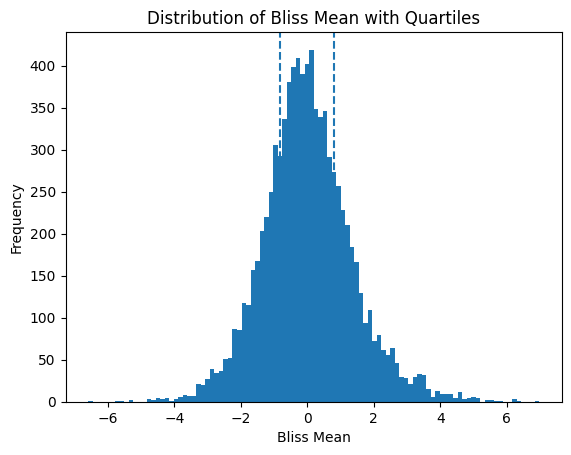

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["bliss_mean"], bins=100)
plt.axvline(df["bliss_mean"].quantile(0.25), linestyle='--')
plt.axvline(df["bliss_mean"].quantile(0.75), linestyle='--')
plt.title("Distribution of Bliss Mean with Quartiles")
plt.xlabel("Bliss Mean")
plt.ylabel("Frequency")
plt.show()

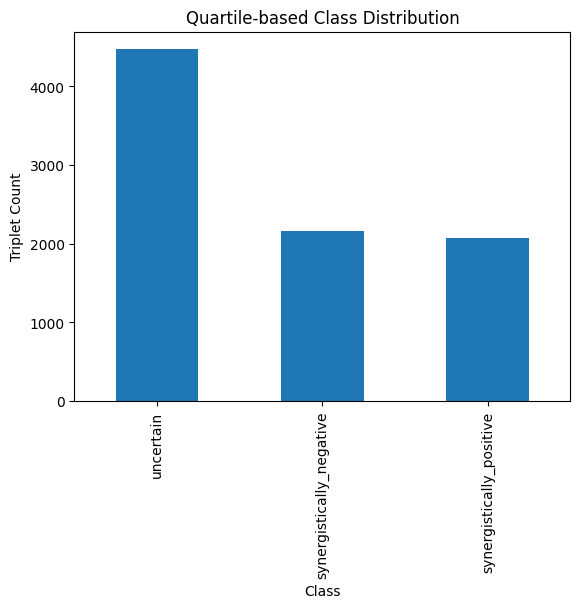

In [5]:
df["synergy_class_q"].value_counts().plot(kind='bar')
plt.title("Quartile-based Class Distribution")
plt.xlabel("Class")
plt.ylabel("Triplet Count")
plt.show()

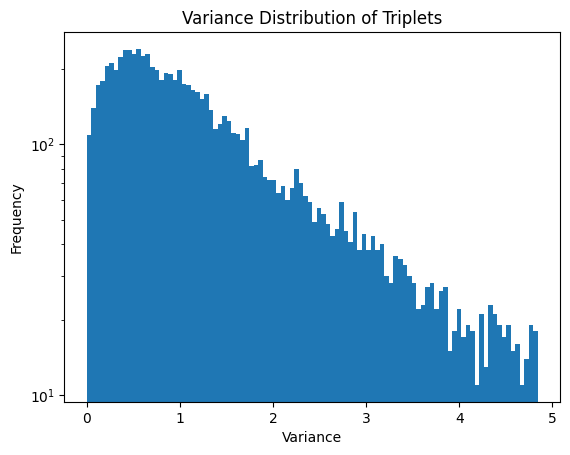

In [23]:
plt.figure()
plt.hist(df["bliss_variance"], bins=100)
plt.title("Variance Distribution of Triplets")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.yscale('log')  # IMPORTANT
plt.show()

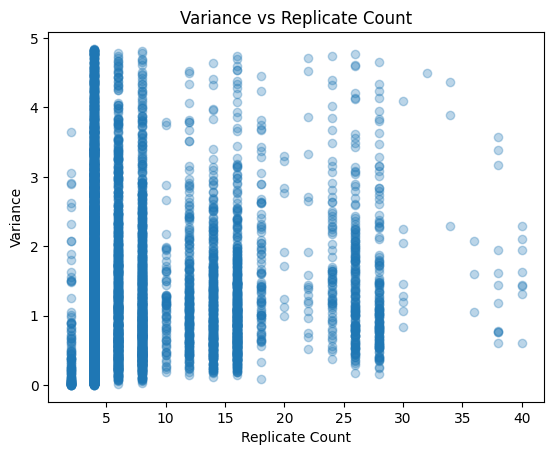

In [24]:
plt.figure()
plt.scatter(df["replicate_count"], df["bliss_variance"], alpha=0.3)
plt.title("Variance vs Replicate Count")
plt.xlabel("Replicate Count")
plt.ylabel("Variance")
plt.show()

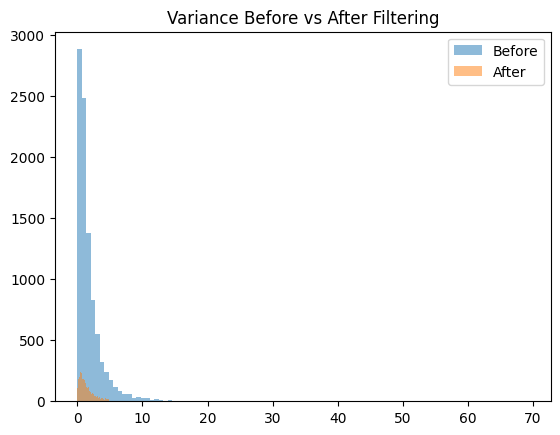

In [28]:
df_before = pd.read_csv(r"D:\bitirme\triplet_stats_quartiles_all.csv")
df_after = pd.read_csv(r"D:\bitirme\matchmaker_newversion\triplet_stats_quartiles_filtered_iqr.csv")




plt.figure()
plt.hist(df_before["bliss_variance"], bins=100, alpha=0.5, label="Before")
plt.hist(df_after["bliss_variance"], bins=100, alpha=0.5, label="After")
plt.legend()
plt.title("Variance Before vs After Filtering")
plt.show()

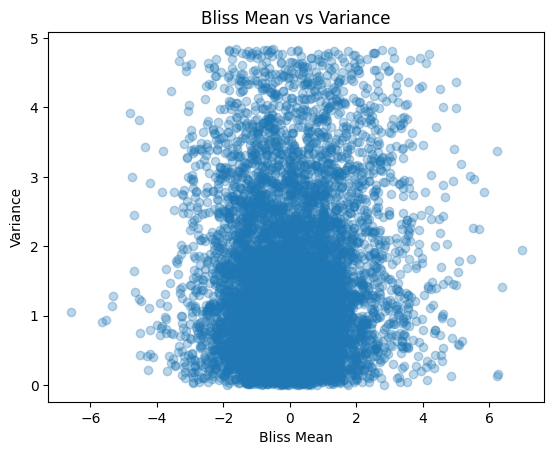

In [29]:
plt.figure()
plt.scatter(df["bliss_mean"], df["bliss_variance"], alpha=0.3)
plt.title("Bliss Mean vs Variance")
plt.xlabel("Bliss Mean")
plt.ylabel("Variance")
plt.show()

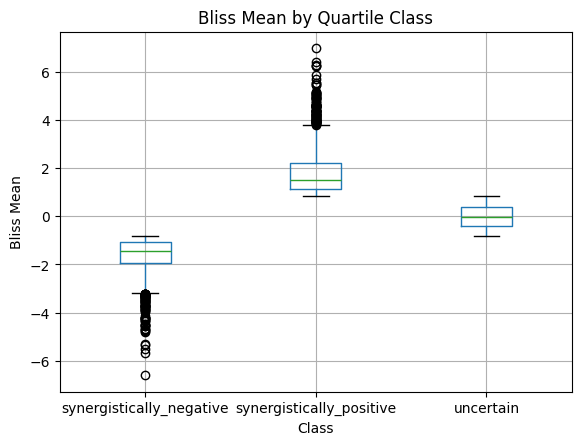

In [30]:
df.boxplot(column="bliss_mean", by="synergy_class_q")
plt.title("Bliss Mean by Quartile Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Bliss Mean")
plt.show()

In [31]:
top_var = df.sort_values("bliss_variance", ascending=False).head(10)

print(top_var[[
    "drugA_name", "drugB_name", "cell_line",
    "bliss_mean", "bliss_variance", "replicate_count"
]])

        drugA_name      drugB_name   cell_line  bliss_mean  bliss_variance  \
5594       AZD7762      Dactolisib      BxPC-3   -1.632622        4.843306   
6031  Galunisertib      Crizotinib  PA-TU-8902   -0.492219        4.838151   
2714       MK-1775      Navitoclax      AsPC-1    2.774281        4.834731   
2871       MK-1775       Sorafenib      AsPC-1   -0.786296        4.833244   
3719      Olaparib         AZD7762  PA-TU-8902   -1.819272        4.830420   
1549     Lapatinib    Galunisertib  MIA-PaCa-2   -0.557788        4.825879   
1301   Palbociclib       Dasatinib  MIA-PaCa-2    0.236615        4.825657   
2598       MK-1775  5-Fluorouracil        PSN1   -0.682258        4.821473   
8209    Linsitinib         MK-2206        KP-2    1.758703        4.820008   
8231    Linsitinib      Irinotecan       DAN-G    0.036941        4.816013   

      replicate_count  
5594                4  
6031                4  
2714                4  
2871                4  
3719                4

In [32]:
uncertain_ratio = (df["synergy_class_q"] == "uncertain").mean()
print("Uncertain ratio:", uncertain_ratio)

Uncertain ratio: 0.5137899333486555


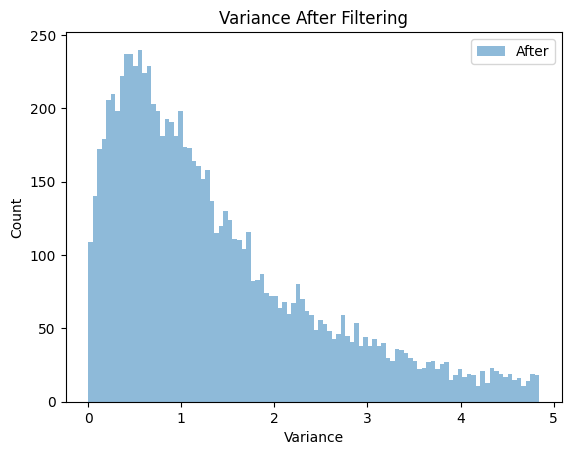

In [37]:
plt.figure()
plt.hist(df_after["bliss_variance"], bins=100, alpha=0.5, label="After")

plt.legend()
plt.title("Variance After Filtering")
plt.xlabel("Variance")
plt.ylabel("Count")
plt.show()

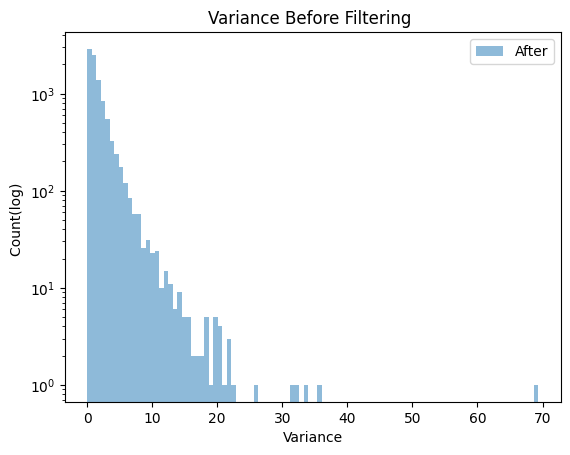

In [40]:
plt.figure()
plt.hist(df_before["bliss_variance"], bins=100, alpha=0.5, label="After")
plt.yscale('log')  # IMPORTANT


plt.legend()
plt.title("Variance Before Filtering ")
plt.xlabel("Variance")
plt.ylabel("Count(log) ")
plt.show()